In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("final_full_datasetMTOR.csv")

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
df.head()

Molecule ChEMBL ID  \
0      CHEMBL6055065   
1      CHEMBL5828123   
2      CHEMBL3407730   
3      CHEMBL3904072   
4      CHEMBL3927821   

                                                                        Smiles  \
0          Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1  Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                      O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3           CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                  CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   

   pChEMBL Value Activity  \
0           7.26   Active   
1           6.26   Active   
2           6.80   Active   
3           5.00   Active   
4           6.10   Active   

                                                              canonical_smiles  \
0          Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1  Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                      O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3           CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                  CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   

     MolWt    LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0  497.559  2.5065       1.0          6.0  111.07                4.0   
1  534.584  2.9461       1.0          7.0  132.41                4.0   
2  451.464  2.7785       2.0         10.0  130.15                5.0   
3  490.973  2.1419       1.0          9.0  111.47                4.0   
4  479.556  3.7713       0.0          6.0   74.41                7.0   

   NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  \
0      37.0            37.0            10.0        27.0           7.0   
1      40.0            40.0            12.0        28.0          10.0   
2      32.0            32.0            11.0        21.0           5.0   
3      33.0            33.0            12.0        21.0           6.0   
4      35.0            35.0             9.0        26.0           5.0   

   NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  NumTripleBonds  \
0         3.0          0.0      42.0             2.0             0.0   
1         2.0          0.0      46.0             2.0             0.0   
2         5.0          0.0      36.0             3.0             0.0   
3         4.0          1.0      38.0             2.0             0.0   
4         3.0          1.0      39.0             1.0             0.0   

   NumRings  NumAromaticRings  NumAliphaticRings  NumSaturatedRings  \
0       6.0               5.0                1.0                1.0   
1       7.0               6.0                1.0                1.0   
2       5.0               4.0                1.0                1.0   
3       6.0               3.0                3.0                2.0   
4       5.0               4.0                1.0                1.0   

   NumAromaticAtoms  NumAliphaticAtoms  FractionCSP3  morgan_0  morgan_1  \
0              24.0               13.0      0.296296         0         0   
1              29.0               11.0      0.250000         0         0   
2              19.0               13.0      0.190476         0         0   
3              15.0               18.0      0.476190         0         0   
4              19.0               16.0      0.423077         0         0   

   morgan_2  morgan_3  morgan_4  morgan_5  morgan_6  morgan_7  morgan_8  \
0         0         0         0         0         0         0         0   
1         0         0         0         0         0         0         0   
2         0         0         0         0         0         0         0   
3         0         0         0         0         0         0         0   
4         0         0         0         0         0         0         0   

   morgan_9  morgan_10  morgan_11  morgan_12  morgan_13 

In [4]:
df.info()   # Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4295 entries, 0 to 4294
Columns: 5148 entries, Molecule ChEMBL ID to rdk_2047
dtypes: float64(24), int64(5120), object(4)
memory usage: 168.7+ MB


In [5]:
df.shape   # No. of Features and Datapoints

(4295, 5148)

In [6]:
df = df[[c for c in df.columns if (
    'morgan' in c.lower() 
    or not any(fp in c.lower() for fp in ['rdk', 'atompair', 'maccs', 'pubchem'])
)]]

In [7]:
df

Molecule ChEMBL ID  \
0         CHEMBL6055065   
1         CHEMBL5828123   
2         CHEMBL3407730   
3         CHEMBL3904072   
4         CHEMBL3927821   
...                 ...   
4290      CHEMBL5778222   
4291      CHEMBL5961664   
4292      CHEMBL5829379   
4293      CHEMBL6175619   
4294      CHEMBL6017578   

                                                                           Smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

      pChEMBL Value  Activity  \
0              7.26    Active   
1              6.26    Active   
2              6.80    Active   
3              5.00    Active   
4              6.10    Active   
...             ...       ...   
4290           5.53    Active   
4291           6.08    Active   
4292           5.00    Active   
4293           4.40  Inactive   
4294           5.19    Active   

                                                                 canonical_smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

        MolWt    LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0     497.559  2.5065       1.0          6.0  111.07                4.0   
1     534.584  2.9461       1.0          7.0  132.41                4.0   
2     451.464  2.7785       2.0         10.0  130.15                5.0   
3     490.973  2.1419       1.0          9.0  111.47                4.0   
4     479.556  3.7713       0.0          6.0   74.41                7.0   
...       ...     ...       ...          ...     ...                ...   
4290  428.489  2.6754       1.0          7.0   98.41                5.0   
4291  414.462  2.5343       1.0          7.0   98.41                4.0   
4292  436.537  3.3873       1.0          7.0   84.42                6.0   
4293  516.627  4.6755       2.0          8.0   91.85                5.0   
4294  449.536  3.0176       2.0          7.0  114.20                5.0   

      NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  \
0         37.0            37.0            10.0        27.0           7.0   
1         40.0            40.0            12.0        28.0          10.0   
2         32.0            32.0            11.0        21.0           5.0   
3         33.0            33.0      

# eliminating zeros

In [8]:
# Calculate sum of numeric features only
feature_sum = df.sum(numeric_only=True)

# Find features with sum = 0
zero_features = feature_sum[feature_sum == 0].index

# Remove those features
df = df.drop(columns=zero_features)

print("Removed columnsandronew:", len(zero_features))

Removed columnsandronew: 39


In [9]:
df

Molecule ChEMBL ID  \
0         CHEMBL6055065   
1         CHEMBL5828123   
2         CHEMBL3407730   
3         CHEMBL3904072   
4         CHEMBL3927821   
...                 ...   
4290      CHEMBL5778222   
4291      CHEMBL5961664   
4292      CHEMBL5829379   
4293      CHEMBL6175619   
4294      CHEMBL6017578   

                                                                           Smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

      pChEMBL Value  Activity  \
0              7.26    Active   
1              6.26    Active   
2              6.80    Active   
3              5.00    Active   
4              6.10    Active   
...             ...       ...   
4290           5.53    Active   
4291           6.08    Active   
4292           5.00    Active   
4293           4.40  Inactive   
4294           5.19    Active   

                                                                 canonical_smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

        MolWt    LogP  H_Donors  H_Acceptors    TPSA  NumRotatableBonds  \
0     497.559  2.5065       1.0          6.0  111.07                4.0   
1     534.584  2.9461       1.0          7.0  132.41                4.0   
2     451.464  2.7785       2.0         10.0  130.15                5.0   
3     490.973  2.1419       1.0          9.0  111.47                4.0   
4     479.556  3.7713       0.0          6.0   74.41                7.0   
...       ...     ...       ...          ...     ...                ...   
4290  428.489  2.6754       1.0          7.0   98.41                5.0   
4291  414.462  2.5343       1.0          7.0   98.41                4.0   
4292  436.537  3.3873       1.0          7.0   84.42                6.0   
4293  516.627  4.6755       2.0          8.0   91.85                5.0   
4294  449.536  3.0176       2.0          7.0  114.20                5.0   

      NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  NumNitrogens  \
0         37.0            37.0            10.0        27.0           7.0   
1         40.0            40.0            12.0        28.0          10.0   
2         32.0            32.0            11.0        21.0           5.0   
3         33.0            33.0      

# missing values 

In [10]:
df.isnull().sum()

Molecule ChEMBL ID    0
Smiles                0
pChEMBL Value         0
Activity              0
canonical_smiles      0
                     ..
morgan_2043           0
morgan_2044           0
morgan_2045           0
morgan_2046           0
morgan_2047           0
Length: 2037, dtype: int64

In [11]:
print(df.shape)

(4295, 2037)


In [12]:
df = df.drop_duplicates(subset = ['Molecule ChEMBL ID', 'canonical_smiles'])

In [13]:
df.drop(['Molecule ChEMBL ID', 'canonical_smiles'], axis = 1, inplace = True)

In [14]:
df

Smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

      pChEMBL Value  Activity    MolWt    LogP  H_Donors  H_Acceptors    TPSA  \
0              7.26    Active  497.559  2.5065       1.0          6.0  111.07   
1              6.26    Active  534.584  2.9461       1.0          7.0  132.41   
2              6.80    Active  451.464  2.7785       2.0         10.0  130.15   
3              5.00    Active  490.973  2.1419       1.0          9.0  111.47   
4              6.10    Active  479.556  3.7713       0.0          6.0   74.41   
...             ...       ...      ...     ...       ...          ...     ...   
4290           5.53    Active  428.489  2.6754       1.0          7.0   98.41   
4291           6.08    Active  414.462  2.5343       1.0          7.0   98.41   
4292           5.00    Active  436.537  3.3873       1.0          7.0   84.42   
4293           4.40  Inactive  516.627  4.6755       2.0          8.0   91.85   
4294           5.19    Active  449.536  3.0176       2.0          7.0  114.20   

      NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  \
0                   4.0      37.0            37.0            10.0        27.0   
1                   4.0      40.0            40.0            12.0        28.0   
2                   5.0      32.0            32.0            11.0        21.0   
3                   4.0      33.0            33.0            12.0        21.0   
4                   7.0      35.0            35.0             9.0        26.0   
...                 ...       ...             ...             ...         ...   
4290                5.0      30.0            30.0             9.0        21.0   
4291                4.0      29.0            29.0             9.0        20.0   
4292                6.0      31.0            31.0             8.0        23.0   
4293                5.0      37.0            37.0            10.0        27.0   
4294                5.0      32.0            32.0             9.0        23.0   

      NumNitrogens  NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  \
0              7.0         3.0          0.0      42.0             2.0   
1             10.0         2.0          0.0      46.0             2.0   
2              5.0         5.0          0.0      36.0             3.0   
3              6.0         4.0          1.0      38.0             2.0   
4              5.0         3.0          1.0      39.0             1.0   
...            ...         ...          ...       ...             ...   
4290           4.0         3.0          1.0      33.0             2.0   
4291           4.0         3.0          1.0      32.0             2.0   
4292           4.0         3.0          0.0      35.0             2.0   
4293           6.0         3.0          0.0      42.0             1.0   
4294           5.0         3.0          0.0      36.0             2.0   

      NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings  \
0                0.0       6.0               5.0                1.0   
1                0.0       7.0               6.0                1.0   
2                0

# label encoding 

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Activity"] = le.fit_transform(df["Activity"])

In [17]:
df['Activity'].value_counts()

Activity
0    4161
1     134
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

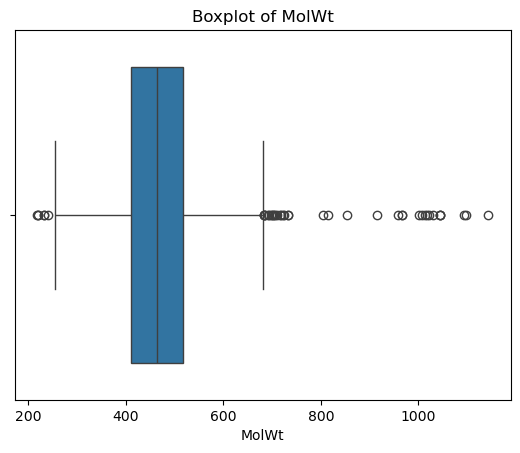

In [19]:
sns.boxplot (x =df ['MolWt'])
plt.title ("Boxplot of MolWt")
plt.show()

In [20]:
numeric_cols = ["MolWt", "LogP", "H_Acceptors","H_Donors", "TPSA","NumRotatableBonds"]

Outliers ={}
for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
         
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR 
        
        Outliers[col]=df[(df[col]<lower)| (df[col]>upper)]
        
        print (f"{col} : {len(Outliers [col])} outlier detected")

MolWt : 43 outlier detected
LogP : 119 outlier detected
H_Acceptors : 91 outlier detected
H_Donors : 54 outlier detected
TPSA : 68 outlier detected
NumRotatableBonds : 32 outlier detected


# removing outliers

In [21]:
df = df[(df[col] >= lower) & (df[col] <= upper)]
df

Smiles  \
0             Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)CO)C3)c(=O)n5C)cn2)cn1   
1     Cn1cc(-c2ccc(-c3ccc4ncc5c(c4c3)n(C3CCCN(C(=O)c4nc[nH]n4)C3)c(=O)n5C)cn2)cn1   
2                         O=C(O)c1ccc2occ(/C=N/Nc3nc(N4CCOCC4)c4ccsc4n3)c(=O)c2c1   
3              CNc1nc2ccc(Cl)cc2n1-c1nc2c(c(C3(S(C)(=O)=O)CC3)n1)OC[C@@H]1COCCN21   
4                     CN(C)CCCOc1ccc(-c2ccc3ncc4c(c3c2)n(C2CCOCC2)c(=O)n4C)c(F)n1   
...                                                                           ...   
4290                          Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3ccccc3F)c2)cn1   
4291                         Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)c3ccc(F)cc3)c2)cn1   
4292                       O=S(=O)(c1ccccc1)c1cc(-c2cnc(NC3CC3)nc2)cc(N2CCOCC2)c1   
4293                  O=C(Nc1ccc(-c2cc(N3CCOCC3)c3nc(N4CCOCC4)sc3c2)cc1)Nc1cccnc1   
4294                   Nc1ncc(-c2cc(N3CCOCC3)cc(S(=O)(=O)Cc3c[nH]c4ccccc34)c2)cn1   

      pChEMBL Value  Activity    MolWt    LogP  H_Donors  H_Acceptors    TPSA  \
0              7.26         0  497.559  2.5065       1.0          6.0  111.07   
1              6.26         0  534.584  2.9461       1.0          7.0  132.41   
2              6.80         0  451.464  2.7785       2.0         10.0  130.15   
3              5.00         0  490.973  2.1419       1.0          9.0  111.47   
4              6.10         0  479.556  3.7713       0.0          6.0   74.41   
...             ...       ...      ...     ...       ...          ...     ...   
4290           5.53         0  428.489  2.6754       1.0          7.0   98.41   
4291           6.08         0  414.462  2.5343       1.0          7.0   98.41   
4292           5.00         0  436.537  3.3873       1.0          7.0   84.42   
4293           4.40         1  516.627  4.6755       2.0          8.0   91.85   
4294           5.19         0  449.536  3.0176       2.0          7.0  114.20   

      NumRotatableBonds  NumAtoms  HeavyAtomCount  NumHeteroatoms  NumCarbons  \
0                   4.0      37.0            37.0            10.0        27.0   
1                   4.0      40.0            40.0            12.0        28.0   
2                   5.0      32.0            32.0            11.0        21.0   
3                   4.0      33.0            33.0            12.0        21.0   
4                   7.0      35.0            35.0             9.0        26.0   
...                 ...       ...             ...             ...         ...   
4290                5.0      30.0            30.0             9.0        21.0   
4291                4.0      29.0            29.0             9.0        20.0   
4292                6.0      31.0            31.0             8.0        23.0   
4293                5.0      37.0            37.0            10.0        27.0   
4294                5.0      32.0            32.0             9.0        23.0   

      NumNitrogens  NumOxygens  NumHalogens  NumBonds  NumDoubleBonds  \
0              7.0         3.0          0.0      42.0             2.0   
1             10.0         2.0          0.0      46.0             2.0   
2              5.0         5.0          0.0      36.0             3.0   
3              6.0         4.0          1.0      38.0             2.0   
4              5.0         3.0          1.0      39.0             1.0   
...            ...         ...          ...       ...             ...   
4290           4.0         3.0          1.0      33.0             2.0   
4291           4.0         3.0          1.0      32.0             2.0   
4292           4.0         3.0          0.0      35.0             2.0   
4293           6.0         3.0          0.0      42.0             1.0   
4294           5.0         3.0          0.0      36.0             2.0   

      NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings  \
0                0.0       6.0               5.0                1.0   
1                0.0       7.0               6.0                1.0   
2                0

# removing corelated factors 

In [22]:
import numpy as np

# Columns that must NOT be used for correlation-based deletion
exclude_columns = [
    "Activity",
    "pChEMBL Value"
]

# Select only numeric columns except target and pChEMBL
numeric_df = df.select_dtypes(include=["number"]).drop(
    columns=exclude_columns,
    errors="ignore"
)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Store correlated features
correlated_features = set()

# Check only the upper triangle of correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i):

        correlation = correlation_matrix.iloc[i, j]

        if abs(correlation) > 0.80:

            colname = correlation_matrix.columns[i]

            correlated_features.add(colname)


# Display results
print("Number of correlated features to remove:",
      len(correlated_features))

print("\nCorrelated features:")
print(correlated_features)

Number of correlated features to remove: 188

Correlated features:
{'morgan_1862', 'morgan_1669', 'NumAtoms', 'morgan_1990', 'morgan_785', 'morgan_564', 'morgan_624', 'morgan_726', 'morgan_1349', 'morgan_1127', 'morgan_2029', 'morgan_600', 'morgan_1606', 'morgan_1784', 'morgan_1124', 'morgan_950', 'morgan_644', 'morgan_1510', 'morgan_1518', 'morgan_1570', 'morgan_812', 'morgan_1970', 'morgan_1904', 'morgan_1921', 'morgan_1109', 'morgan_1854', 'morgan_1459', 'morgan_1536', 'morgan_860', 'morgan_1210', 'morgan_1856', 'morgan_966', 'morgan_602', 'morgan_1252', 'morgan_213', 'morgan_781', 'morgan_1963', 'morgan_1954', 'morgan_419', 'morgan_1577', 'morgan_931', 'morgan_1733', 'morgan_176', 'morgan_1609', 'morgan_857', 'morgan_1377', 'morgan_1077', 'morgan_1539', 'morgan_1989', 'morgan_1693', 'morgan_1636', 'morgan_1661', 'morgan_1513', 'morgan_1905', 'morgan_2041', 'morgan_851', 'morgan_674', 'morgan_1247', 'morgan_454', 'morgan_1075', 'morgan_1694', 'morgan_2036', 'morgan_1984', 'morgan_11

In [23]:
df.drop(
    columns=list(correlated_features),
    inplace=True
)

print("Correlated features removed successfully.")

print("New dataset shape:")
print(df.shape)

Correlated features removed successfully.
New dataset shape:
(4263, 1847)


C:\Users\sahan\AppData\Local\Temp\ipykernel_11724\1558483522.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(


# train and split

In [24]:
print(df.groupby("Activity")["pChEMBL Value"].agg(["min", "max", "count"]))

          min    max  count
Activity                   
0         5.0  10.15   4129
1         4.0   4.99    134


In [25]:
print(df["Activity"].value_counts())

Activity
0    4129
1     134
Name: count, dtype: int64


In [26]:
df["Activity"]

0       0
1       0
2       0
3       0
4       0
       ..
4290    0
4291    0
4292    0
4293    1
4294    0
Name: Activity, Length: 4263, dtype: int64

In [27]:
# Correct the activity labels

df["Activity"] = 1 - df["Activity"]

print(df["Activity"].value_counts())

Activity
1    4129
0     134
Name: count, dtype: int64


C:\Users\sahan\AppData\Local\Temp\ipykernel_11724\959254278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Activity"] = 1 - df["Activity"]


In [28]:
print(
    df.groupby("Activity")["pChEMBL Value"]
      .agg(["min", "max", "count"])
)

          min    max  count
Activity                   
0         4.0   4.99    134
1         5.0  10.15   4129


In [29]:
df = df.copy()

In [30]:
# Features and target

X = df.drop(
    columns=["Activity", "pChEMBL Value"],
    errors="ignore"
)

y = df["Activity"]

# Keep only numerical ML features
X = X.select_dtypes(include=["number"])

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

X shape: (4263, 1844)
y shape: (4263,)

Class distribution:
Activity
1    4129
0     134
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

X_train shape: (3410, 1844)
X_test shape: (853, 1844)

Training class distribution:
Activity
1    3303
0     107
Name: count, dtype: int64

Test class distribution:
Activity
1    826
0     27
Name: count, dtype: int64


# smote analysis 

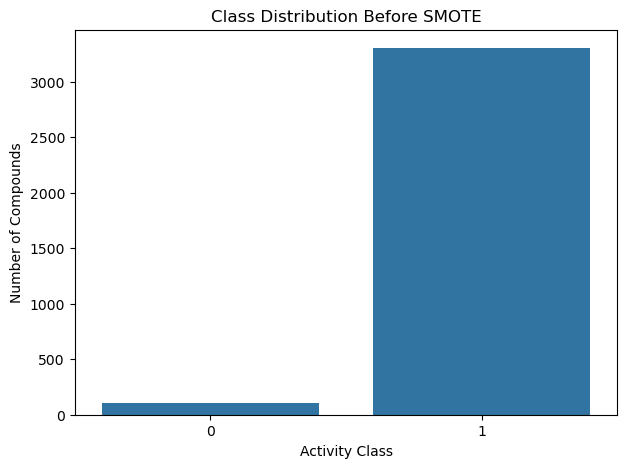

In [32]:
# Class distribution before SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution Before SMOTE")

plt.show()

In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Activity
1    3303
0     107
Name: count, dtype: int64

After SMOTE:
Activity
1    3303
0    3303
Name: count, dtype: int64


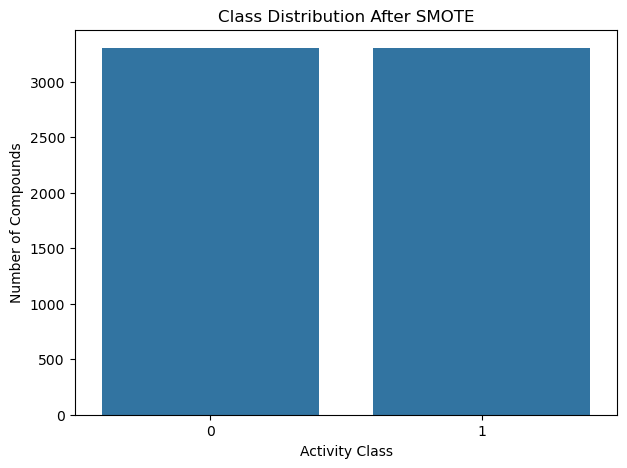

In [34]:
# Class distribution after SMOTE

plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.xlabel("Activity Class")
plt.ylabel("Number of Compounds")
plt.title("Class Distribution After SMOTE")

plt.show()

# logistic regression 

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [36]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

LR = LogisticRegression(max_iter=1000)

LR.fit(X_train_sm, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
LR_predict = LR.predict(X_test_scaled)

In [38]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, LR_predict))

print(classification_report(
    y_test,
    LR_predict,
    target_names=["Inactive", "Active"],
    digits=4
))

Accuracy_score = 0.9695193434935522
              precision    recall  f1-score   support

    Inactive     0.5185    0.5185    0.5185        27
      Active     0.9843    0.9843    0.9843       826

    accuracy                         0.9695       853
   macro avg     0.7514    0.7514    0.7514       853
weighted avg     0.9695    0.9695    0.9695       853



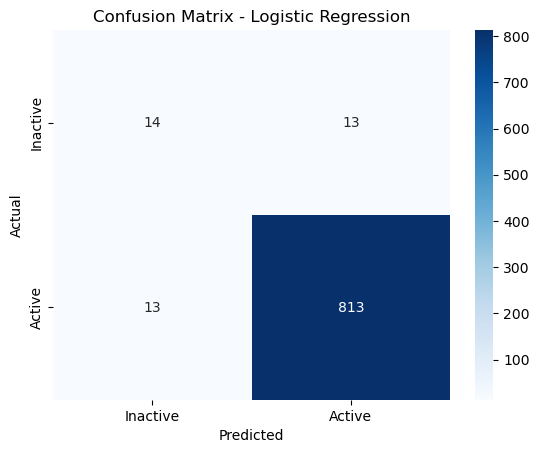

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, LR_predict)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

LR ROC AUC = 0.820


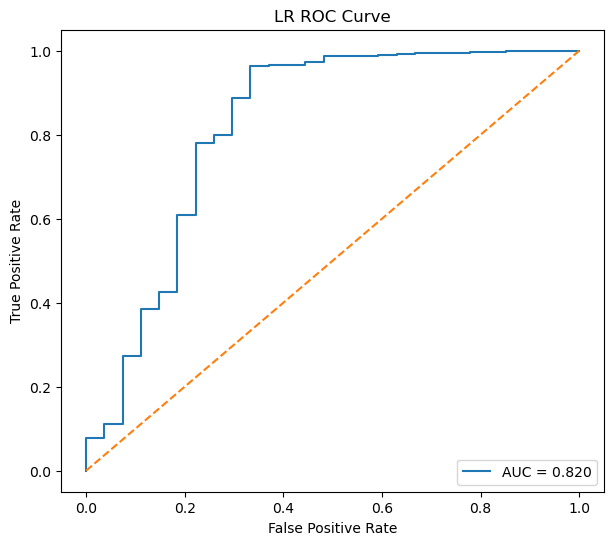

In [40]:
from sklearn.metrics import roc_curve, auc

LR_prob = LR.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    LR_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LR ROC Curve")

plt.legend(loc="lower right")

print("LR ROC AUC = %.3f" % roc_auc)

plt.show()

# decision tree

In [41]:
from sklearn.tree import DecisionTreeClassifier

In [42]:
DT = DecisionTreeClassifier(
    random_state=42
)

DT.fit(
    X_train_smote,
    y_train_smote
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
DT_predict = DT.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, DT_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        DT_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9660023446658851

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.4706    0.5926    0.5246        27
      Active     0.9866    0.9782    0.9824       826

    accuracy                         0.9660       853
   macro avg     0.7286    0.7854    0.7535       853
weighted avg     0.9702    0.9660    0.9679       853



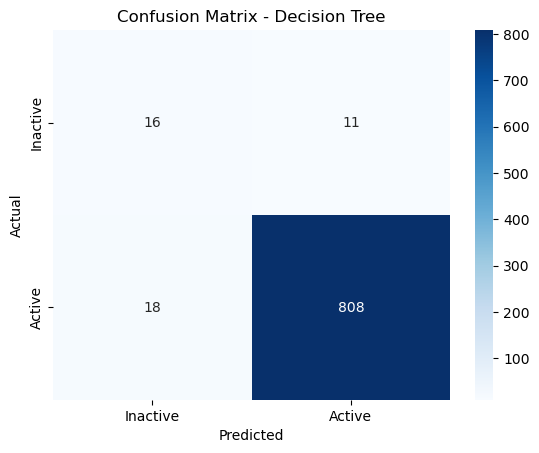

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    DT_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

Decision Tree ROC AUC = 0.785


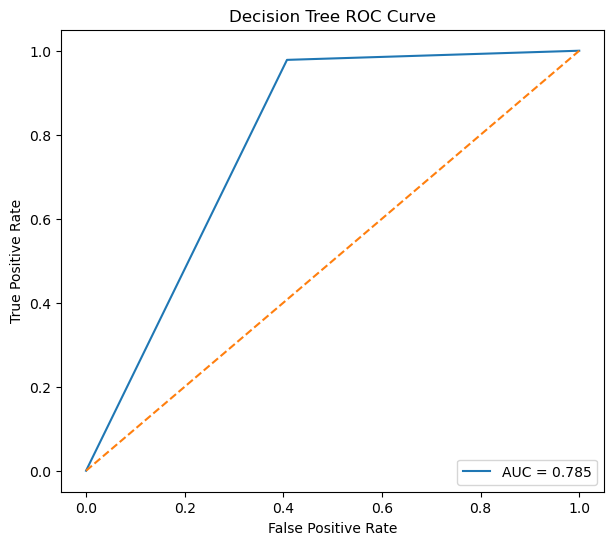

In [46]:
from sklearn.metrics import roc_curve, auc

DT_prob = DT.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    DT_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend(loc="lower right")

print("Decision Tree ROC AUC = %.3f" % roc_auc)

plt.show()

# random forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
RF = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RF.fit(
    X_train_smote,
    y_train_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
RF_predict = RF.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, RF_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        RF_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.977725674091442

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6818    0.5556    0.6122        27
      Active     0.9856    0.9915    0.9885       826

    accuracy                         0.9777       853
   macro avg     0.8337    0.7735    0.8004       853
weighted avg     0.9759    0.9777    0.9766       853



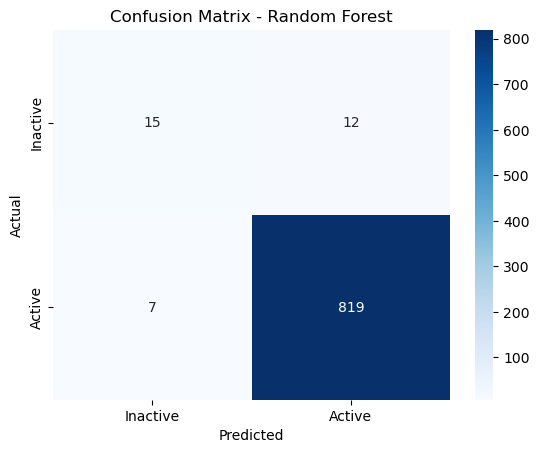

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    RF_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

Random Forest ROC AUC = 0.955


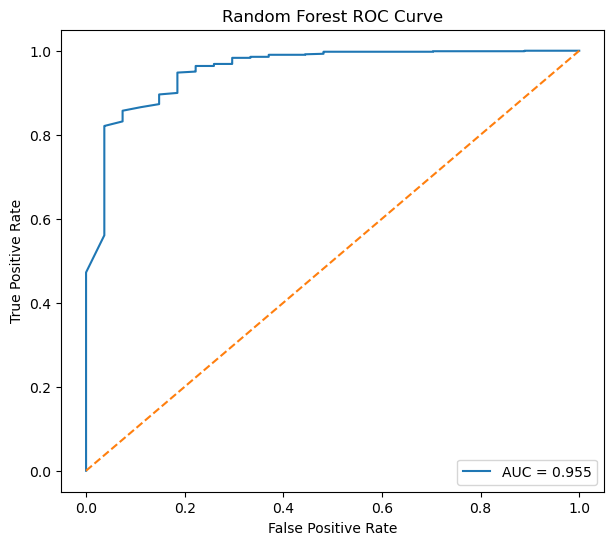

In [52]:
from sklearn.metrics import roc_curve, auc

RF_prob = RF.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    RF_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")

plt.legend(loc="lower right")

print("Random Forest ROC AUC = %.3f" % roc_auc)

plt.show()

# XGBOOST

In [53]:
from xgboost import XGBClassifier

In [54]:
XGB = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

XGB.fit(
    X_train_smote,
    y_train_smote
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [55]:
XGB_predict = XGB.predict(X_test)

In [56]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, XGB_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        XGB_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.977725674091442

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6667    0.5926    0.6275        27
      Active     0.9867    0.9903    0.9885       826

    accuracy                         0.9777       853
   macro avg     0.8267    0.7915    0.8080       853
weighted avg     0.9766    0.9777    0.9771       853



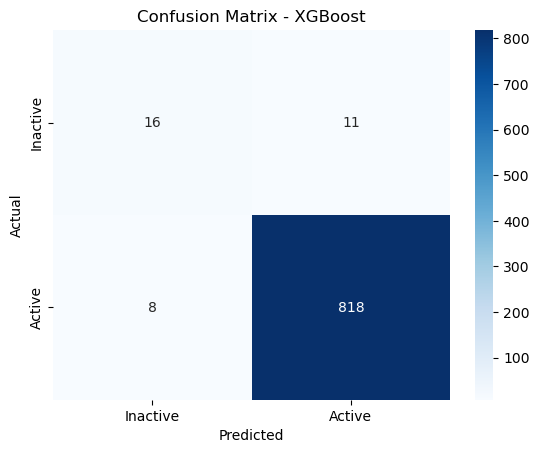

In [57]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    XGB_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

XGBoost ROC AUC = 0.952


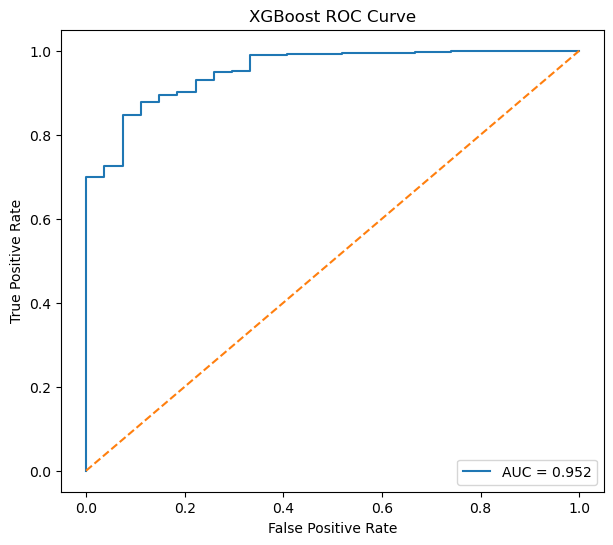

In [58]:
from sklearn.metrics import roc_curve, auc

XGB_prob = XGB.predict_proba(X_test)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    XGB_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")

plt.legend(loc="lower right")

print("XGBoost ROC AUC = %.3f" % roc_auc)

plt.show()

# support vector machine 

In [59]:
from sklearn.svm import SVC

In [60]:
SVM = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

SVM.fit(
    X_train_sm,
    y_train_smote
)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [61]:
SVM_predict = SVM.predict(X_test_scaled)

In [62]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, SVM_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        SVM_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.9706916764361079

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.5625    0.3333    0.4186        27
      Active     0.9785    0.9915    0.9850       826

    accuracy                         0.9707       853
   macro avg     0.7705    0.6624    0.7018       853
weighted avg     0.9653    0.9707    0.9670       853



SVM ROC AUC = 0.851


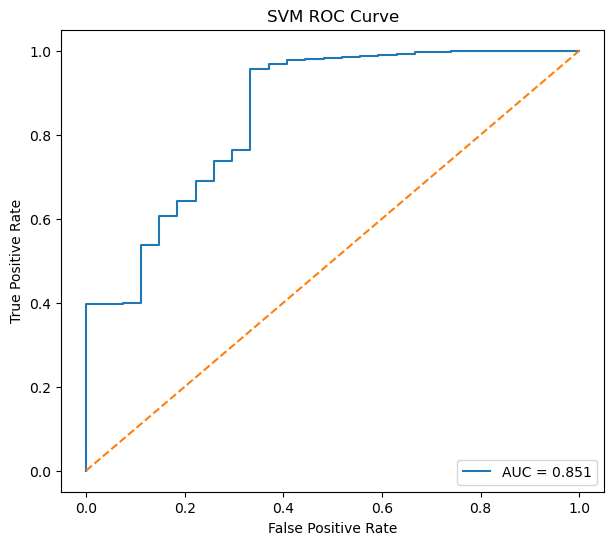

In [63]:
from sklearn.metrics import roc_curve, auc

SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    SVM_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")

plt.legend(loc="lower right")

print("SVM ROC AUC = %.3f" % roc_auc)

plt.show()

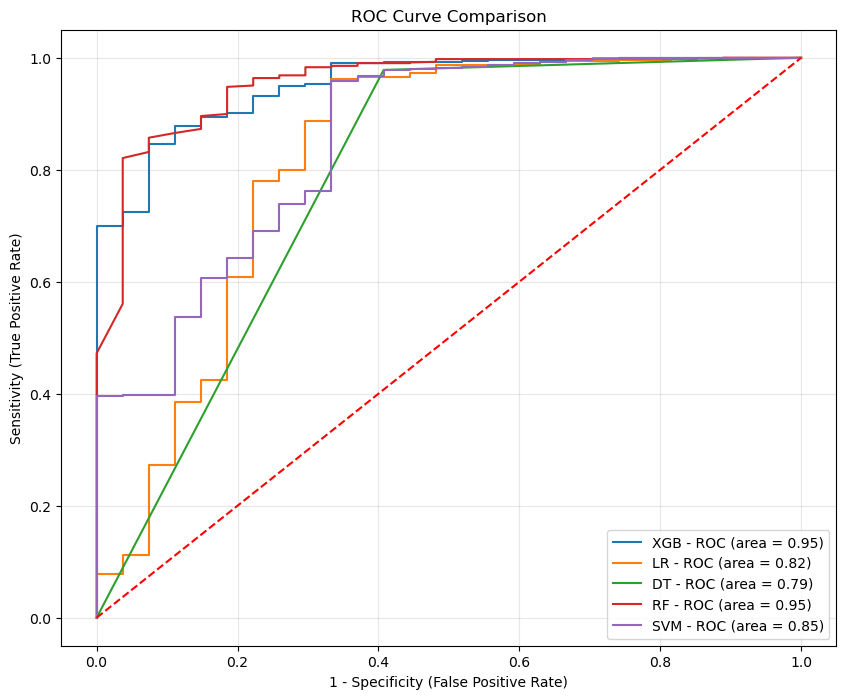

Logistic Regression AUC: 0.82
Decision Tree AUC: 0.785
Random Forest AUC: 0.955
XGBoost AUC: 0.952
SVM AUC: 0.851


In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability predictions for each model
LR_prob = LR.predict_proba(X_test_scaled)[:, 1]
DT_prob = DT.predict_proba(X_test)[:, 1]
RF_prob = RF.predict_proba(X_test)[:, 1]
XGB_prob = XGB.predict_proba(X_test)[:, 1]
SVM_prob = SVM.predict_proba(X_test_scaled)[:, 1]


# Calculate ROC curves
fpr_LR, tpr_LR, _ = roc_curve(y_test, LR_prob)
fpr_DT, tpr_DT, _ = roc_curve(y_test, DT_prob)
fpr_RF, tpr_RF, _ = roc_curve(y_test, RF_prob)
fpr_XGB, tpr_XGB, _ = roc_curve(y_test, XGB_prob)
fpr_SVM, tpr_SVM, _ = roc_curve(y_test, SVM_prob)


# Calculate AUC
auc_LR = auc(fpr_LR, tpr_LR)
auc_DT = auc(fpr_DT, tpr_DT)
auc_RF = auc(fpr_RF, tpr_RF)
auc_XGB = auc(fpr_XGB, tpr_XGB)
auc_SVM = auc(fpr_SVM, tpr_SVM)


# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(
    fpr_XGB, tpr_XGB,
    label="XGB - ROC (area = %.2f)" % auc_XGB
)

plt.plot(
    fpr_LR, tpr_LR,
    label="LR - ROC (area = %.2f)" % auc_LR
)

plt.plot(
    fpr_DT, tpr_DT,
    label="DT - ROC (area = %.2f)" % auc_DT
)

plt.plot(
    fpr_RF, tpr_RF,
    label="RF - ROC (area = %.2f)" % auc_RF
)

plt.plot(
    fpr_SVM, tpr_SVM,
    label="SVM - ROC (area = %.2f)" % auc_SVM
)


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    "r--"
)


plt.xlabel("1 - Specificity (False Positive Rate)")
plt.ylabel("Sensitivity (True Positive Rate)")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")

plt.grid(True, alpha=0.3)

plt.show()


# Print AUC values
print("Logistic Regression AUC:", round(auc_LR, 3))
print("Decision Tree AUC:", round(auc_DT, 3))
print("Random Forest AUC:", round(auc_RF, 3))
print("XGBoost AUC:", round(auc_XGB, 3))
print("SVM AUC:", round(auc_SVM, 3))

In [65]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# SMOTE + Random Forest
rfecv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", rf_model)
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RFECV
rfecv = RFECV(
    estimator=rfecv_pipeline,
    step=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    min_features_to_select=10,
    importance_getter="named_steps.rf.feature_importances_"
)

# Run RFECV ONLY on training data
rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 1844


In [66]:
selected_features = X_train.columns[rfecv.support_]

print("Number of selected features:", len(selected_features))

print("\nSelected features:")
print(selected_features.tolist())

Number of selected features: 1844

Selected features:
['MolWt', 'LogP', 'H_Donors', 'H_Acceptors', 'TPSA', 'NumRotatableBonds', 'NumHeteroatoms', 'NumNitrogens', 'NumOxygens', 'NumHalogens', 'NumDoubleBonds', 'NumTripleBonds', 'NumRings', 'NumAromaticRings', 'NumAliphaticRings', 'FractionCSP3', 'morgan_0', 'morgan_1', 'morgan_2', 'morgan_3', 'morgan_4', 'morgan_5', 'morgan_6', 'morgan_7', 'morgan_8', 'morgan_9', 'morgan_10', 'morgan_11', 'morgan_12', 'morgan_13', 'morgan_14', 'morgan_15', 'morgan_16', 'morgan_18', 'morgan_19', 'morgan_20', 'morgan_21', 'morgan_22', 'morgan_23', 'morgan_24', 'morgan_25', 'morgan_26', 'morgan_27', 'morgan_28', 'morgan_29', 'morgan_30', 'morgan_31', 'morgan_32', 'morgan_33', 'morgan_34', 'morgan_35', 'morgan_36', 'morgan_37', 'morgan_38', 'morgan_39', 'morgan_40', 'morgan_41', 'morgan_42', 'morgan_43', 'morgan_44', 'morgan_45', 'morgan_46', 'morgan_47', 'morgan_48', 'morgan_49', 'morgan_50', 'morgan_51', 'morgan_52', 'morgan_53', 'morgan_54', 'morgan_55',

In [67]:
X_train_rfecv = X_train[selected_features]
X_test_rfecv = X_test[selected_features]

print("Original number of features:", X_train.shape[1])
print("RFECV selected features:", X_train_rfecv.shape[1])

print("X_train RFECV shape:", X_train_rfecv.shape)
print("X_test RFECV shape:", X_test_rfecv.shape)

Original number of features: 1844
RFECV selected features: 1844
X_train RFECV shape: (3410, 1844)
X_test RFECV shape: (853, 1844)


In [68]:
from imblearn.over_sampling import SMOTE

smote_rfecv = SMOTE(random_state=42)

X_train_rfecv_smote, y_train_rfecv_smote = smote_rfecv.fit_resample(
    X_train_rfecv,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_rfecv_smote.value_counts())

Before SMOTE:
Activity
1    3303
0     107
Name: count, dtype: int64

After SMOTE:
Activity
1    3303
0    3303
Name: count, dtype: int64


In [69]:
from sklearn.ensemble import RandomForestClassifier

RF_RFECV = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

RF_RFECV.fit(
    X_train_rfecv_smote,
    y_train_rfecv_smote
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [70]:
RF_RFECV_predict = RF_RFECV.predict(X_test_rfecv)

In [71]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy_score =", accuracy_score(y_test, RF_RFECV_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        RF_RFECV_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy_score = 0.977725674091442

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6818    0.5556    0.6122        27
      Active     0.9856    0.9915    0.9885       826

    accuracy                         0.9777       853
   macro avg     0.8337    0.7735    0.8004       853
weighted avg     0.9759    0.9777    0.9766       853



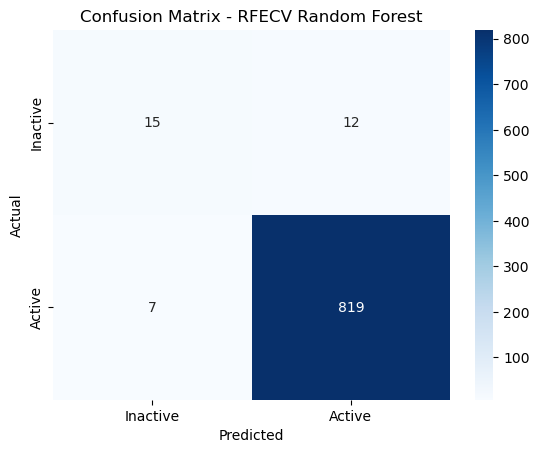

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    RF_RFECV_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RFECV Random Forest")

plt.show()

RFECV Random Forest ROC AUC = 0.955


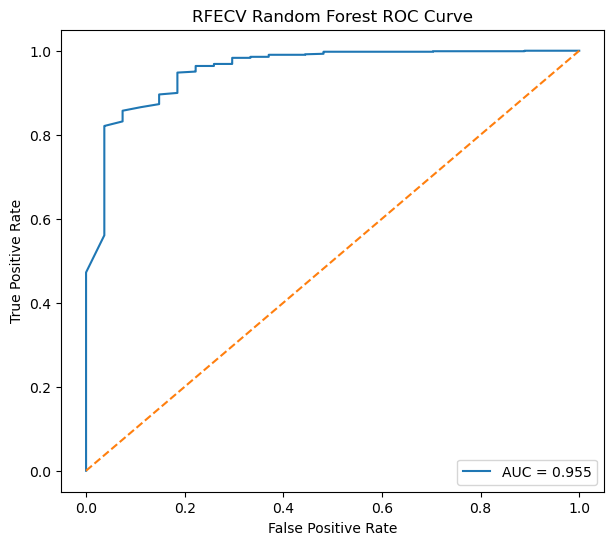

In [73]:
from sklearn.metrics import roc_curve, auc

RF_RFECV_prob = RF_RFECV.predict_proba(X_test_rfecv)[:, 1]

fpr, tpr, threshold = roc_curve(
    y_test,
    RF_RFECV_prob,
    pos_label=1
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % roc_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RFECV Random Forest ROC Curve")

plt.legend(loc="lower right")

print("RFECV Random Forest ROC AUC = %.3f" % roc_auc)

plt.show()

In [74]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("Selected training features:", X_train_selected.shape)
print("Selected test features:", X_test_selected.shape)

Selected training features: (3410, 1844)
Selected test features: (853, 1844)


# hyperparameter tuning

In [75]:
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [76]:
def objective(trial):

    n_estimators = trial.suggest_int(
        "n_estimators", 50, 500
    )

    max_depth = trial.suggest_int(
        "max_depth", 2, 50
    )

    min_samples_split = trial.suggest_int(
        "min_samples_split", 2, 10
    )

    min_samples_leaf = trial.suggest_int(
        "min_samples_leaf", 1, 5
    )

    max_features = trial.suggest_categorical(
        "max_features",
        ["sqrt", "log2"]
    )

    model = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("rf", RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        model,
        X_train_selected,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()

In [77]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=30
)

[I 2026-09-06 11:13:44,384] A new study created in memory with name: no-name-0451482a-e9e0-4861-9cdb-9b93cccae15f
[I 2026-09-06 11:13:54,727] Trial 0 finished with value: 0.9424547794386882 and parameters: {'n_estimators': 319, 'max_depth': 49, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.9424547794386882.
[I 2026-09-06 11:14:22,956] Trial 1 finished with value: 0.9511232965448342 and parameters: {'n_estimators': 395, 'max_depth': 28, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9511232965448342.
[I 2026-09-06 11:14:53,739] Trial 2 finished with value: 0.9568180895343597 and parameters: {'n_estimators': 462, 'max_depth': 19, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9568180895343597.
[I 2026-09-06 11:14:59,548] Trial 3 finished with value: 0.9077654157148037 and parameters: {'n_estimators': 95, 'max_depth': 6, 'min

In [78]:
print("Best ROC-AUC:", study.best_value)

print("\nBest Parameters:")
print(study.best_params)

Best ROC-AUC: 0.9592736459432925

Best Parameters:
{'n_estimators': 487, 'max_depth': 22, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


# k fold validation

In [79]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

final_RF = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("rf", RandomForestClassifier(
        n_estimators=283,
        max_depth=40,
        min_samples_split=5,
        min_samples_leaf=1,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

print("Final tuned Random Forest created.")

Final tuned Random Forest created.


In [80]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    final_RF,
    X_train_selected,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold Cross-Validation ROC-AUC Scores:")
print(cv_scores)

print("\nMean ROC-AUC:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

5-Fold Cross-Validation ROC-AUC Scores:
[0.96030545 0.94085441 0.95965709 0.97548209 0.96239669]

Mean ROC-AUC: 0.9597391463805988
Standard Deviation: 0.01106222249856215


In [81]:
final_RF.fit(
    X_train_selected,
    y_train
)

print("Final tuned Random Forest trained successfully.")

Final tuned Random Forest trained successfully.


In [82]:
final_RF_predict = final_RF.predict(
    X_test_selected
)

In [83]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy =", accuracy_score(y_test, final_RF_predict))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        final_RF_predict,
        target_names=["Inactive", "Active"],
        digits=4
    )
)

Accuracy = 0.9765533411488863

Classification Report:
              precision    recall  f1-score   support

    Inactive     0.6522    0.5556    0.6000        27
      Active     0.9855    0.9903    0.9879       826

    accuracy                         0.9766       853
   macro avg     0.8189    0.7729    0.7940       853
weighted avg     0.9750    0.9766    0.9756       853



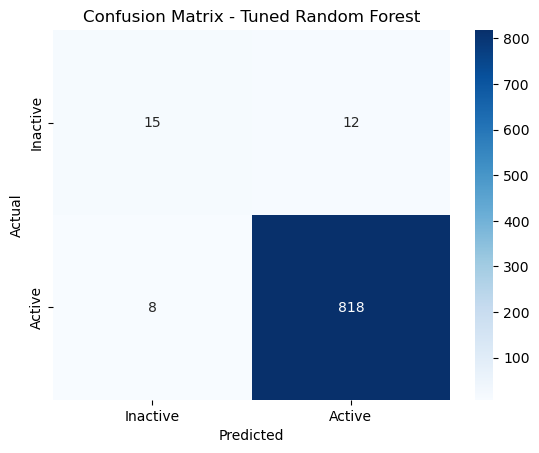

In [84]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    final_RF_predict
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Inactive", "Active"],
    yticklabels=["Inactive", "Active"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")

plt.show()

Final Test ROC-AUC = 0.9606


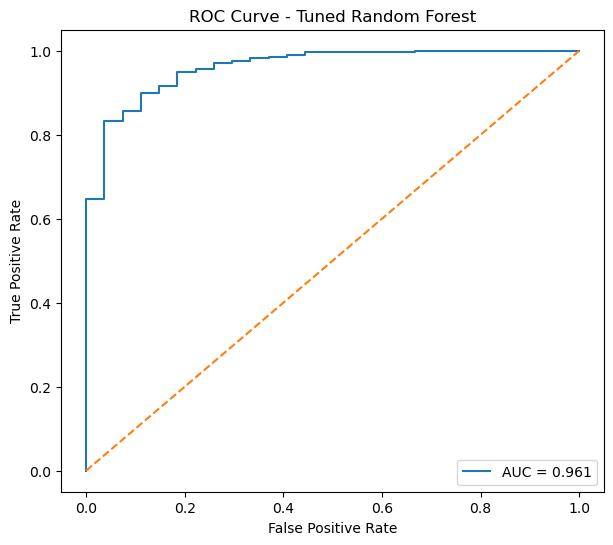

In [85]:
from sklearn.metrics import roc_curve, auc

final_RF_prob = final_RF.predict_proba(
    X_test_selected
)[:, 1]

fpr, tpr, _ = roc_curve(
    y_test,
    final_RF_prob
)

final_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %.3f" % final_auc
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")

plt.legend(loc="lower right")

print("Final Test ROC-AUC =", round(final_auc, 4))

plt.show()

In [86]:
selected_features = X_train.columns[rfecv.support_]

selected_features_df = pd.DataFrame({
    "feature": selected_features
})

selected_features_df.to_csv(
    "rfecv_selected_featuresMTOR.csv",
    index=False
)

print("Selected features saved:", len(selected_features))

Selected features saved: 1844


In [92]:
import pandas as pd

# 1. External compounds
external_df = pd.read_csv("atompair_addedBrain.csv")

# 2. Load the 1,844 features selected by RFECV
selected_df = pd.read_csv("rfecv_selected_featuresMTOR.csv")
selected_features = selected_df["feature"].tolist()

print("Selected features:", len(selected_features))

# 3. Keep ONLY the selected 1,844 features
X_external_selected = external_df[selected_features]

print("External selected matrix:", X_external_selected.shape)

Selected features: 1844
External selected matrix: (77, 1844)


In [93]:
X_external_selected

MolWt     LogP  H_Donors  H_Acceptors   TPSA  NumRotatableBonds  \
0   253.305  2.95110       2.0          4.0  74.16                2.0   
1   265.360  2.69490       1.0          3.0  27.63                5.0   
2   291.347  2.37310       2.0          5.0  71.70                7.0   
3   216.284  1.94450       1.0          3.0  33.62                4.0   
4   213.708  2.37140       2.0          2.0  32.26                4.0   
..      ...      ...       ...          ...    ...                ...   
72  259.349  2.57750       2.0          3.0  41.49                6.0   
73  100.457 -4.12400       1.0          4.0  89.41                0.0   
74  213.321  2.22450       0.0          3.0  29.54                6.0   
75  230.336  2.75392       1.0          3.0  24.39                2.0   
76  232.327  2.49892       1.0          3.0  33.62                4.0   

    NumHeteroatoms  NumNitrogens  NumOxygens  NumHalogens  NumDoubleBonds  \
0              4.0           3.0         1.0          0.0             0.0   
1              3.0           3.0         0.0          0.0             1.0   
2              5.0           1.0         4.0          0.0             1.0   
3              3.0           2.0         1.0          0.0             1.0   
4              3.0           1.0         1.0          1.0             0.0   
..             ...           ...         ...          ...             ...   
72             3.0           1.0         2.0          0.0             0.0   
73             5.0           0.0         4.0          1.0             0.0   
74             3.0           1.0         2.0          0.0             2.0   
75             3.0           2.0         0.0          0.0             1.0   
76             3.0           2.0         1.0          0.0             1.0   

    NumTripleBonds  NumRings  NumAromaticRings  NumAliphaticRings  \
0              0.0       3.0               3.0                0.0   
1              0.0       3.0               2.0                1.0   
2              0.0       2.0               2.0                0.0   
3              0.0       3.0               1.0                2.0   
4              0.0       1.0               1.0                0.0   
..             ...       ...               ...                ...   
72             0.0       2.0               2.0                0.0   
73             0.0       0.0               0.0                0.0   
74             0.0       0.0               0.0                0.0   
75             0.0       3.0               2.0                1.0   
76             0.0       2.0               1.0                1.0   

    FractionCSP3  morgan_0  morgan_1  morgan_2  morgan_3  morgan_4  morgan_5  \
0       0.133333         0         0         0         0         0         0   
1       0.235294         0         0         0         0         0         0   
2       0.437500         0         1         0         0         0         0   
3       0.461538         0         0         0         0         0         0   
4       0.454545         0         1         0         0         0         0   
..           ...       ...       ...       ...       ...       ...       ...   
72      0.375000         0         1         0         0         0         0   
73      0.000000         0         0         0         0         0         0   
74      0.750000         0         1         0         0         0         0   
75      0.307692         0         0         0         0         0         0   
76      0.500000         0         1         0         0         0         0   

    morgan_6  morgan_7  morgan_8  morgan_9  morgan_10  morgan_11  morgan_12  \
0          0         0         0         0          0          0          0   
1          0         0         0         0          0          0          0   
2          0         0         0         0          0          0          0   
3          0         0         0         0          0          0          0   
4          0       